# Предсказание стоимости автомобиля
(Сформулируйте название самостоятельно. Постарайтесь отразить в нём суть задачи: предсказание стоимости автомобилей с учётом бизнес-рисков).

# **Часть 1. EDA (Экспресс-анализ данных)**

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

In [1]:
!pip install "scikit-learn==1.6.1" "numpy==2.4.3" "optuna==4.8.0" -U -q
!pip install phik -U -q
!pip install ipywidgets -U -q

ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0 Requires-Python >=3.11; 1.8.0rc1 Requires-Python >=3.11; 1.9.0rc1 Requires-Python >=3.11; 2.1.0 Requires-Python >=3.10; 2.1.1 Requires-Python >=3.10; 2.1.2 Requires-Python >=3.10; 2.1.3 Requires-Python >=3.10; 2.2.0 Requires-Python >=3.10; 2.2.1 Requires-Python >=3.10; 2.2.2 Requires-Python >=3.10; 2.2.3 Requires-Python >=3.10; 2.2.4 Requires-Python >=3.10; 2.2.5 Requires-Python >=3.10; 2.2.6 Requires-Python >=3.10; 2.3.0 Requires-Python >=3.11; 2.3.1 Requires-Python >=3.11; 2.3.2 Requires-Python >=3.11; 2.3.3 Requires-Python >=3.11; 2.3.4 Requires-Python >=3.11; 2.3.5 Requires-Python >=3.11; 2.4.0 Requires-Python >=3.11; 2.4.0rc1 Requires-Python >=3.11; 2.4.1 Requires-Python >=3.11; 2.4.2 Requires-Python >=3.11; 2.4.3 Requires-Python >=3.11; 2.4.4 Requires-Python >=3.11; 2.4.5 Req

In [349]:
#Импорт библиотек
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from phik import phik
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
import numpy as np
import optuna
from IPython.display import display
import shap

In [3]:
# Зафиксируем константы для воспроизводимости
RANDOM_STATE = 42
N_FOLDS = 5

In [4]:
datasets = dict(
    links=dict(
        train='datasets/ds_s16_train_data.csv',
        test='datasets/ds_s16_test_data.csv',
    )
)
for name, link in datasets['links'].items():
    file_path_platform = Path('/' + link)
    file_path_local = Path(link)
    if file_path_platform.exists():
        datasets[name] = pd.read_csv(file_path_platform, sep=',', decimal='.')
        print(f'Загружен файл {file_path_platform}')
    elif file_path_local.exists():
        datasets[name] = pd.read_csv(file_path_local, sep=',', decimal='.')
        print(f'Загружен файл {file_path_local}')
    else:
        print(f'Ошибка загрузки файла - "{name}"')

Загружен файл datasets/ds_s16_train_data.csv
Загружен файл datasets/ds_s16_test_data.csv


In [5]:
# Класс для первичного исследования данных в датафрейме
class DataFrameReporter:
    def __init__(
        self, df, df_name=None, float_round=3,
        percent_format='0.02%', include_all=False
    ):
        self.df = df
        self.df_name = df_name
        self.float_round = float_round
        self.float_format = f'0.0{float_round}f'
        self.percent_format = percent_format
        self.include_all = include_all

    def show_base_info(self):
        if self.df_name:
            print(f'Базовая информация по датасету {self.df_name}:')
            print('-' * 50)
        display(self.df.head(5))
        display(self.df.info())

    def show_report(self):
        if self.df_name:
            print(f'Отчёт по датасету {self.df_name}:')
            print('-' * 50)
        print('Количество столбцов:', self.df.shape[1])
        print('Количество строк:', self.df.shape[0])
        duplicates = self.df.duplicated().sum()
        print('Количество дубликатов:', duplicates)
        print('Доля дубликатов:', format(
            duplicates / self.df.shape[0], self.percent_format
        ))
        num_cols = self.df.select_dtypes(
            include=['int64', 'float64']).columns.tolist()
        if len(num_cols) > 0:
            display(self.df[num_cols].agg(
                ['count', 'min', 'max', 'std', 'mean', 'median']
            ).T.round(self.float_round))
        missing = self.df.isna().sum().sum()
        print('Количество пропусков:', missing)
        if missing:
            display(self.show_missing_stats())
        isna = self.df.isna().mean(axis=None).sum()
        print('Доля пропусков:', format(isna, self.float_format))

    def show_missing_stats(self):
        missing_stats = pd.DataFrame({
            'Кол-во пропусков': self.df.isnull().sum(),
            'Доля пропусков': self.df.isnull().mean().round(4)
        })
        missing_stats = missing_stats[
            missing_stats['Кол-во пропусков'] > 0
        ].sort_values(by='Кол-во пропусков', ascending=False)
        return missing_stats.style.background_gradient(
            cmap='coolwarm'
        ) if not missing_stats.empty else "Пропусков в данных нет"

    def show_duplicates(self, columns=None):
        if not columns:
            columns = self.df.columns
        duplicates_per_column = {
            col: self.df[col].duplicated().sum() for col in columns
        }
        duplicates_per_column_stats = pd.DataFrame.from_dict(
            duplicates_per_column,
            orient='index',
            columns=['Количество дубликатов']
        )
        return duplicates_per_column_stats.style.background_gradient(
            cmap='coolwarm').set_caption("Статистика дубликатов по столбцам")

    def show_implicit_duplicates_stats(self, columns):
        duplicates = {
            col: self.df[col].nunique() - self.df[
                col].str.strip().str.lower().nunique()
            for col in columns
        }
        duplicates_stats = pd.DataFrame(
            list(duplicates.items()),
            columns=["Столбец", "Неявных дубликатов"]
        )
        return duplicates_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption("Статистика неявных дубликатов")

    def show_uniques_stats(self, columns):
        uniques = {}
        unique_values = {}
        for col in columns:
            uniques[col] = self.df[col].nunique()
            unique_values[col] = ', '.join(
                [str(x) for x in self.df[col].unique()]
            )
        uniques_stats = pd.DataFrame(
            list(uniques.items()),
            columns=['Столбец', 'Уникальных значений']
        )
        uniques_stats['Уникальные значения'] = uniques_stats[
            'Столбец'].map(unique_values)

        display(uniques_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption('Статистика уникальных значений'))

In [6]:
reporter = DataFrameReporter(
    datasets['train'], 'train'
)
reporter.show_base_info()

Базовая информация по датасету train:
--------------------------------------------------


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 812.6 KB


None

In [7]:
reporter.show_report()

Отчёт по датасету train:
--------------------------------------------------
Количество столбцов: 13
Количество строк: 8000
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
make_year,8000.0,1995.0,2023.0,8.389,2009.221,2009.00
mileage_kmpl,8000.0,5.0,35.0,5.016,17.946,17.97
engine_cc,8000.0,800.0,5000.0,1289.812,2289.688,2000.00
owner_count,8000.0,1.0,5.0,1.419,3.001,3.00
accidents_reported,8000.0,0.0,5.0,0.694,0.488,0.00
price_rub,8000.0,95000.0,1676525.0,264923.499,683647.872,663866.00


Количество пропусков: 0
Доля пропусков: 0.000


In [8]:
reporter = DataFrameReporter(
    datasets['test'], 'test'
)
reporter.show_base_info()

Базовая информация по датасету test:
--------------------------------------------------


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   str    
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   str    
 6   transmission        2000 non-null   str    
 7   color               2000 non-null   str    
 8   service_history     2000 non-null   str    
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   str    
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 203.3 KB


None

In [9]:
reporter.show_report()


Отчёт по датасету test:
--------------------------------------------------
Количество столбцов: 13
Количество строк: 2000
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
make_year,2000.0,1995.0,2023.00,8.316,2009.150,2009.000
mileage_kmpl,2000.0,5.0,34.38,5.066,18.018,18.005
engine_cc,2000.0,800.0,5000.00,1297.393,2276.900,1800.000
owner_count,2000.0,1.0,5.00,1.418,3.013,3.000
accidents_reported,2000.0,0.0,4.00,0.695,0.509,0.000
price_rub,2000.0,95000.0,1629774.00,268019.599,675791.936,649284.000


Количество пропусков: 0
Доля пропусков: 0.000


In [10]:
# Функция для отрисовки распределения по
def plot_distribution(
        dataset, cols=None,
        figsize=(16, 4), fontsize=12, bins=40, density=True
):
    color = 'steelblue'
    y_label = 'Плотность' if density else 'Частота'
    if not cols:
        cols = dataset.select_dtypes(
            include=['int64', 'float64']).columns.tolist()
    all_data = []
    all_cols = []
    for col in cols:
        fig, axes = plt.subplots(
            1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2, 1]}
        )

        ax1 = axes[0]
        data = dataset[col].dropna()
        all_data.append(data)
        all_cols.append(col)
        ax1.hist(
            data, bins=bins, alpha=0.5, label=col,
            color=color, edgecolor='black', density=density
        )

        ax1.set_title(
            f'Распределение {col}', fontsize=fontsize, fontweight='bold'
        )
        ax1.set_xlabel(col)
        ax1.set_ylabel(y_label)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = axes[1]
        box = ax2.boxplot(
            data, vert=True, patch_artist=True, tick_labels=[col]
        )

        for i, patch in enumerate(box['boxes']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax2.set_ylabel(col)
        ax2.set_title('Ящик с усами', fontsize=fontsize, fontweight='bold')
        ax2.grid(True, alpha=0.2, axis='y')
        plt.tight_layout()
        plt.show()

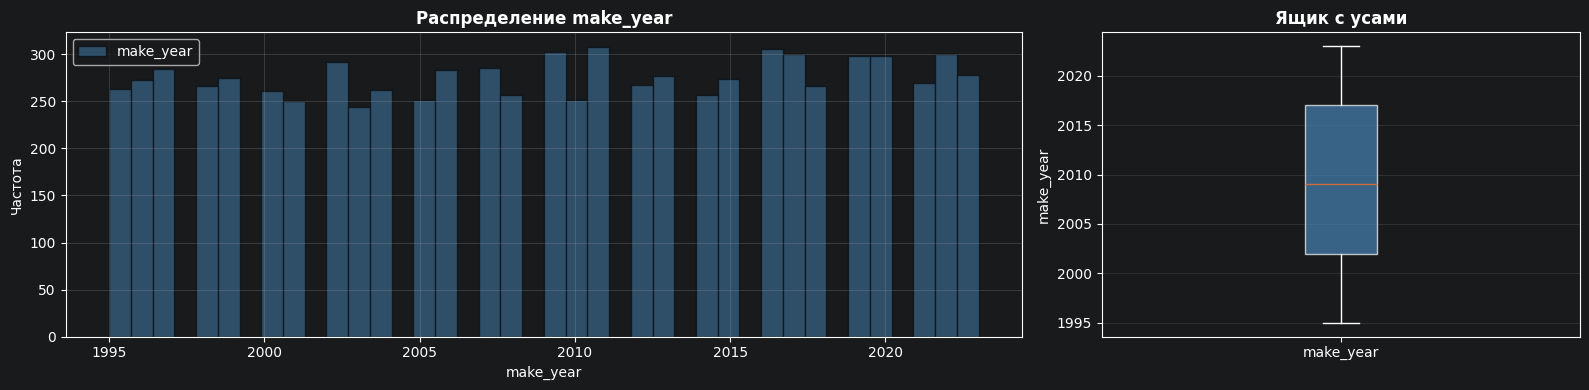

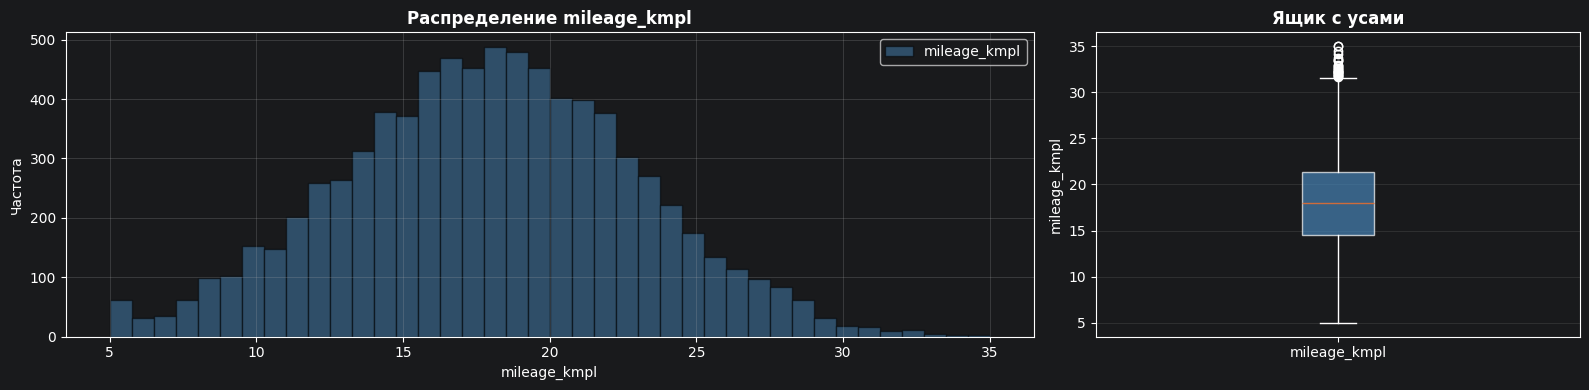

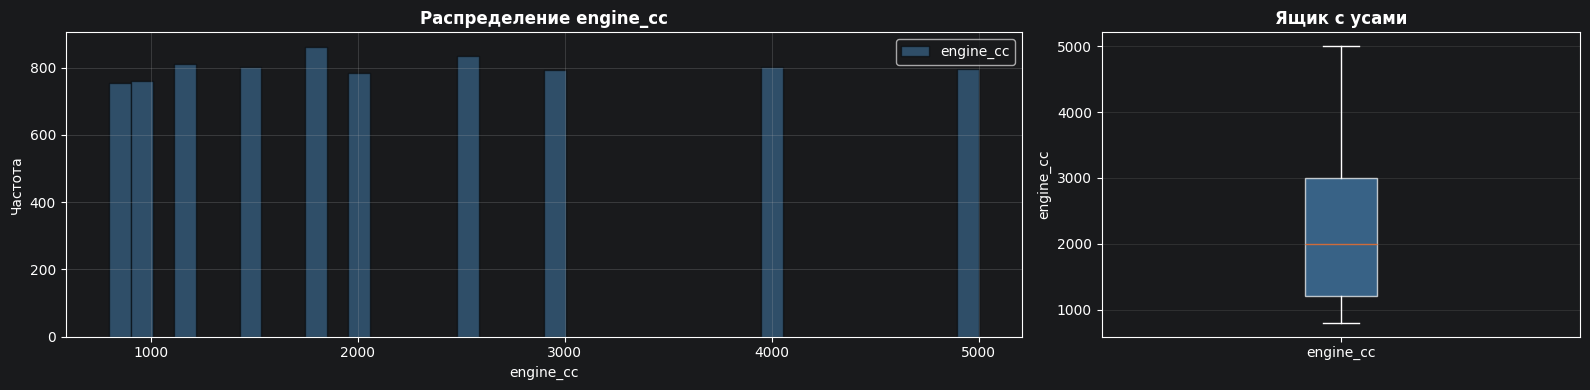

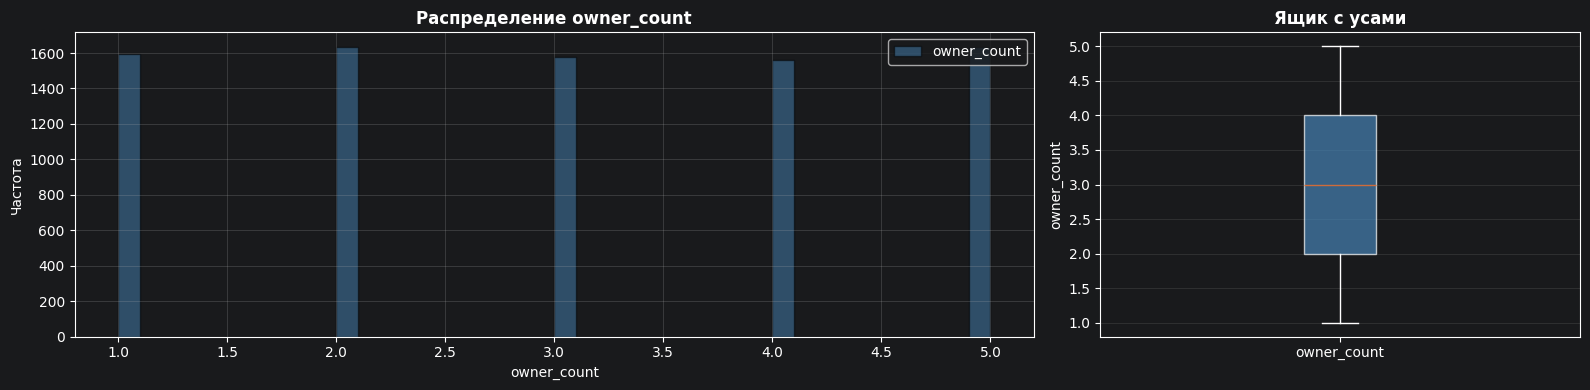

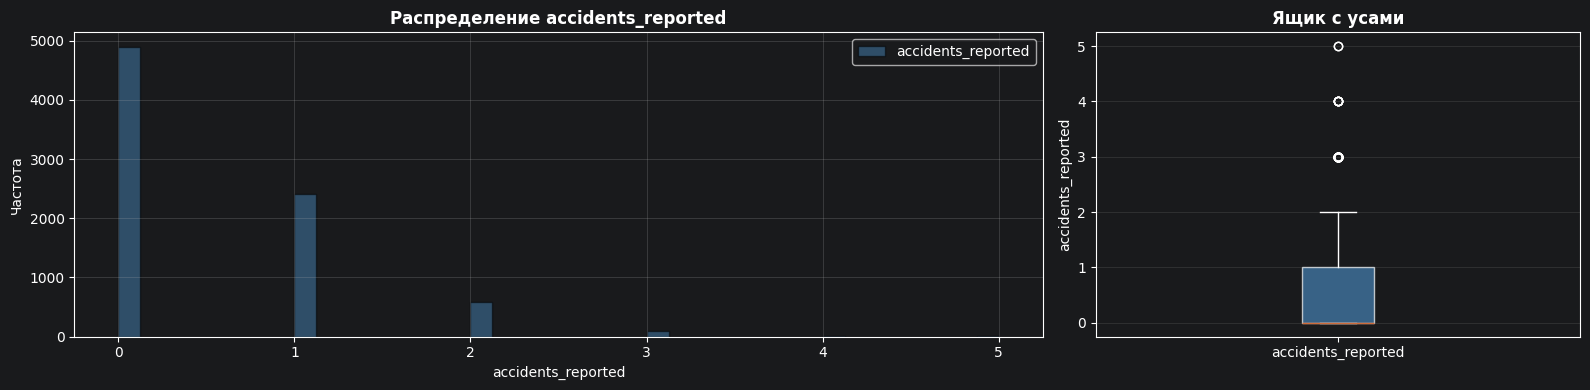

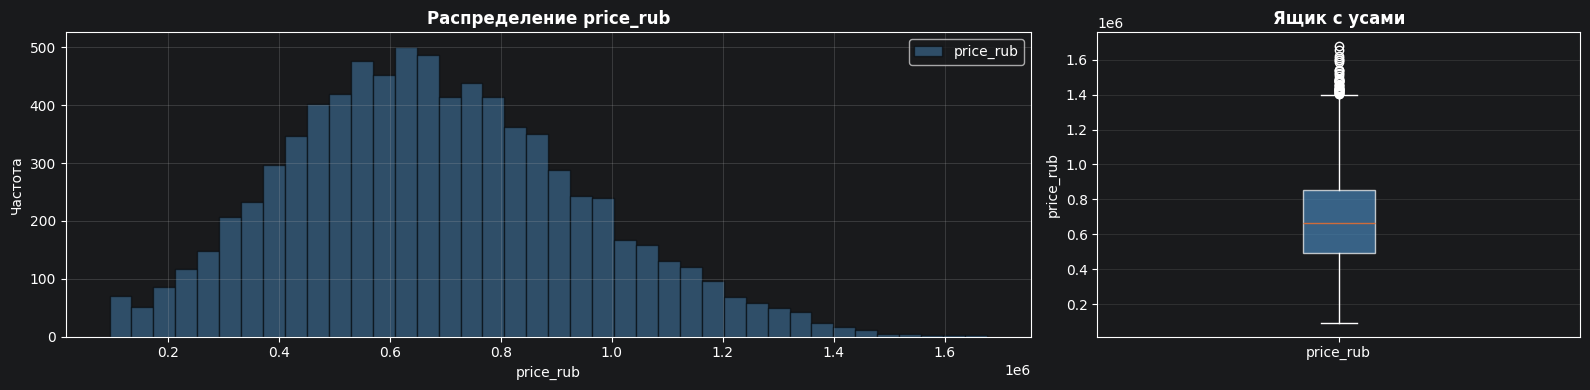

In [11]:
plot_distribution(datasets['train'], density=False)

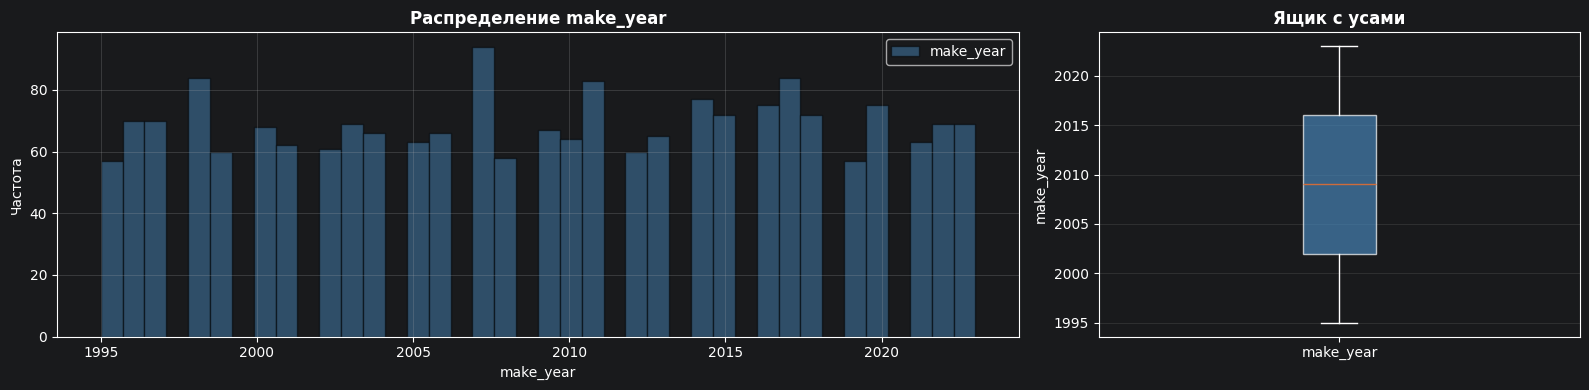

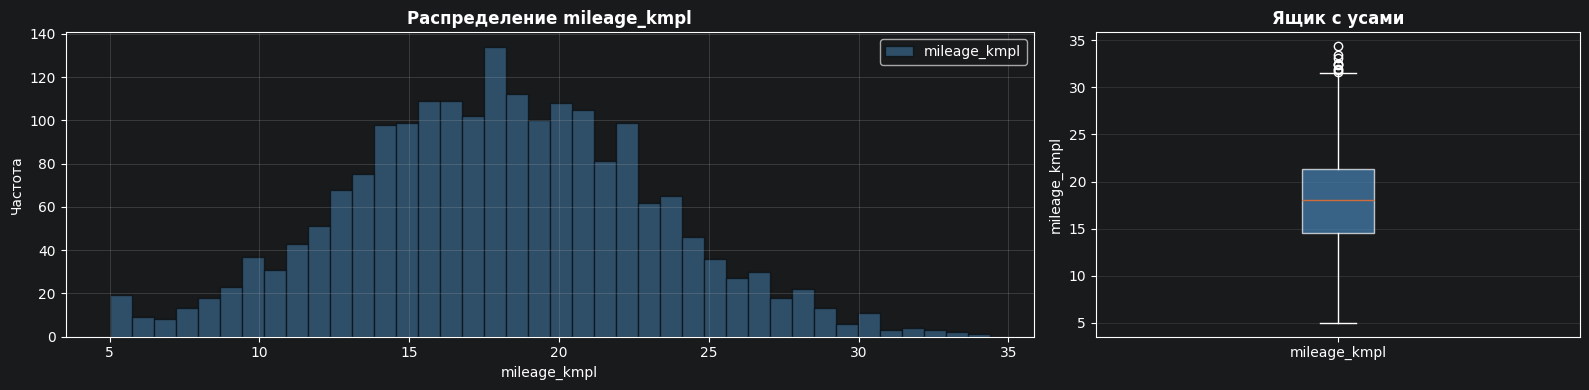

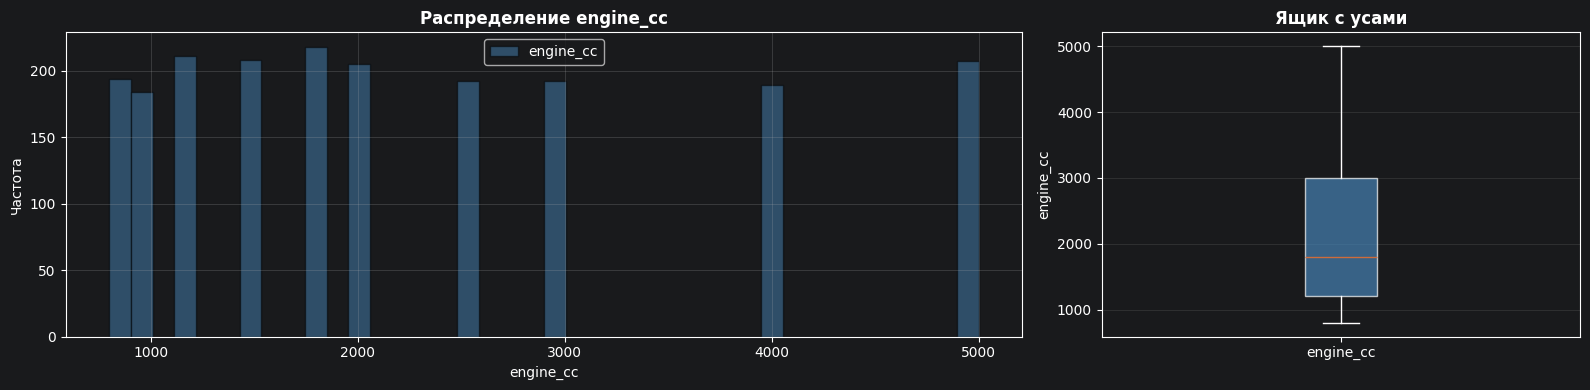

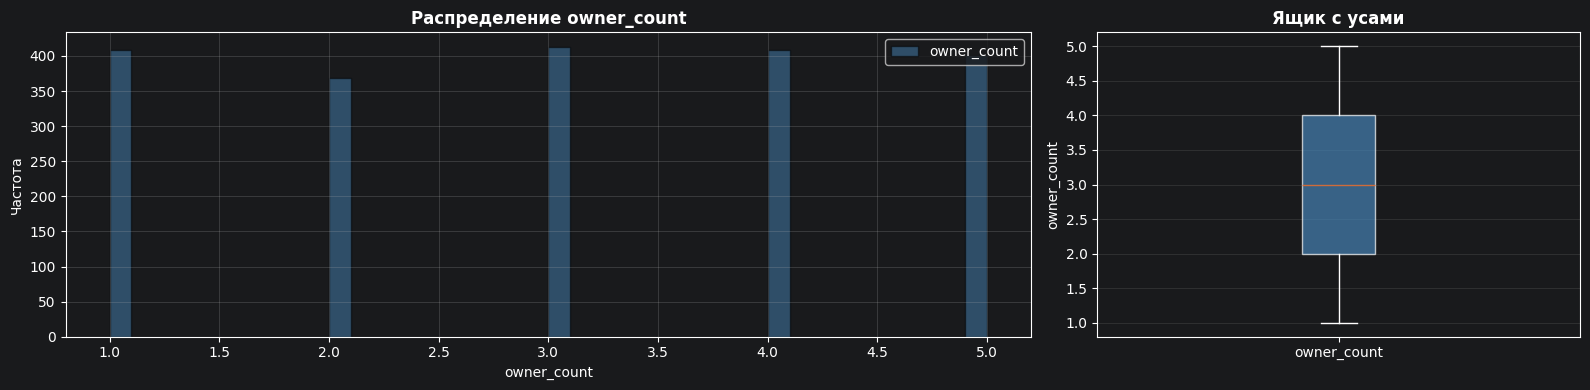

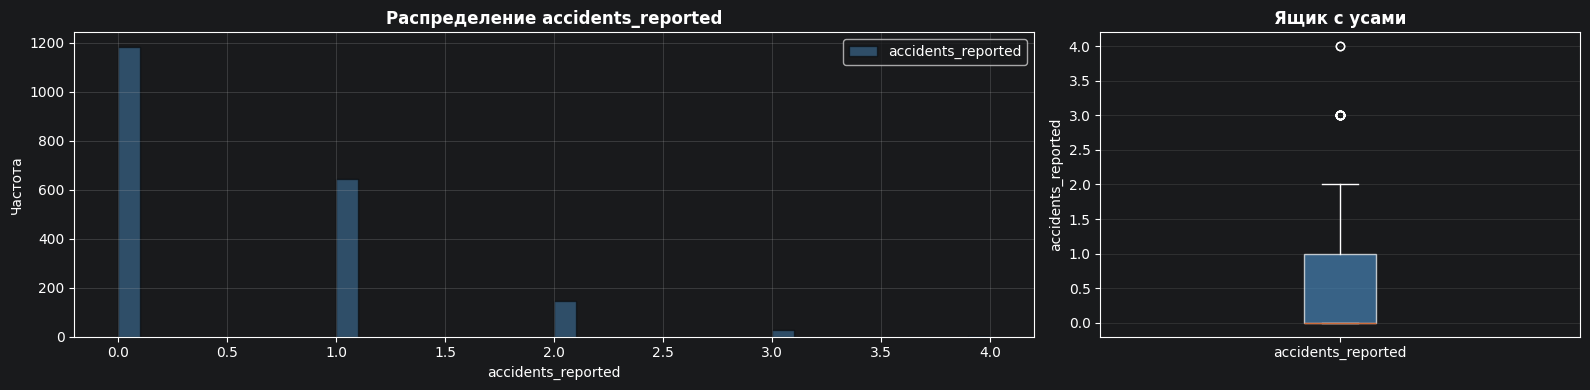

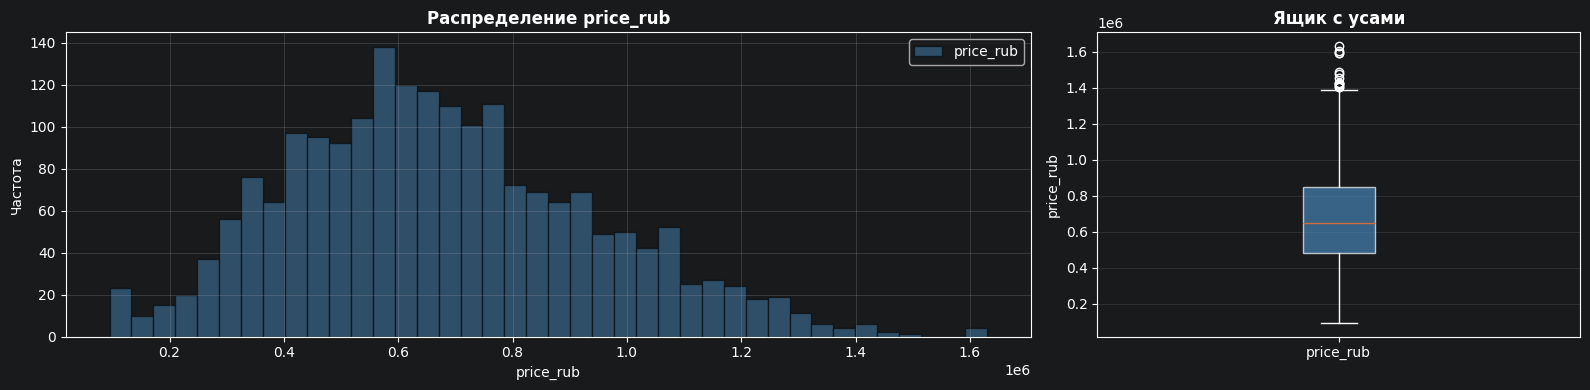

In [12]:
plot_distribution(datasets['test'], density=False)

В двух дата сетах отсутствуют дубликаты и выбросы, распределения по числовым параметрам в двух датасетах подобное.

In [13]:

numeric_features = [
    'make_year',
    'mileage_kmpl',
    'engine_cc',
    'owner_count',
    'accidents_reported',
    'price_rub',
]
columns = datasets['train'].columns.tolist()
correlation_matrix = phik.phik_matrix(
    datasets['train'][columns],
    interval_cols=numeric_features,
    bins=5, verbose=False
)

In [14]:
# Строим тепловую карту коэффициента phi_k
def plot_heatmap(corr_matrix):
    plt.figure(figsize=(30, 20))
    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
               )
    plt.title('Тепловая карта коэффициента phi_k')
    plt.show()

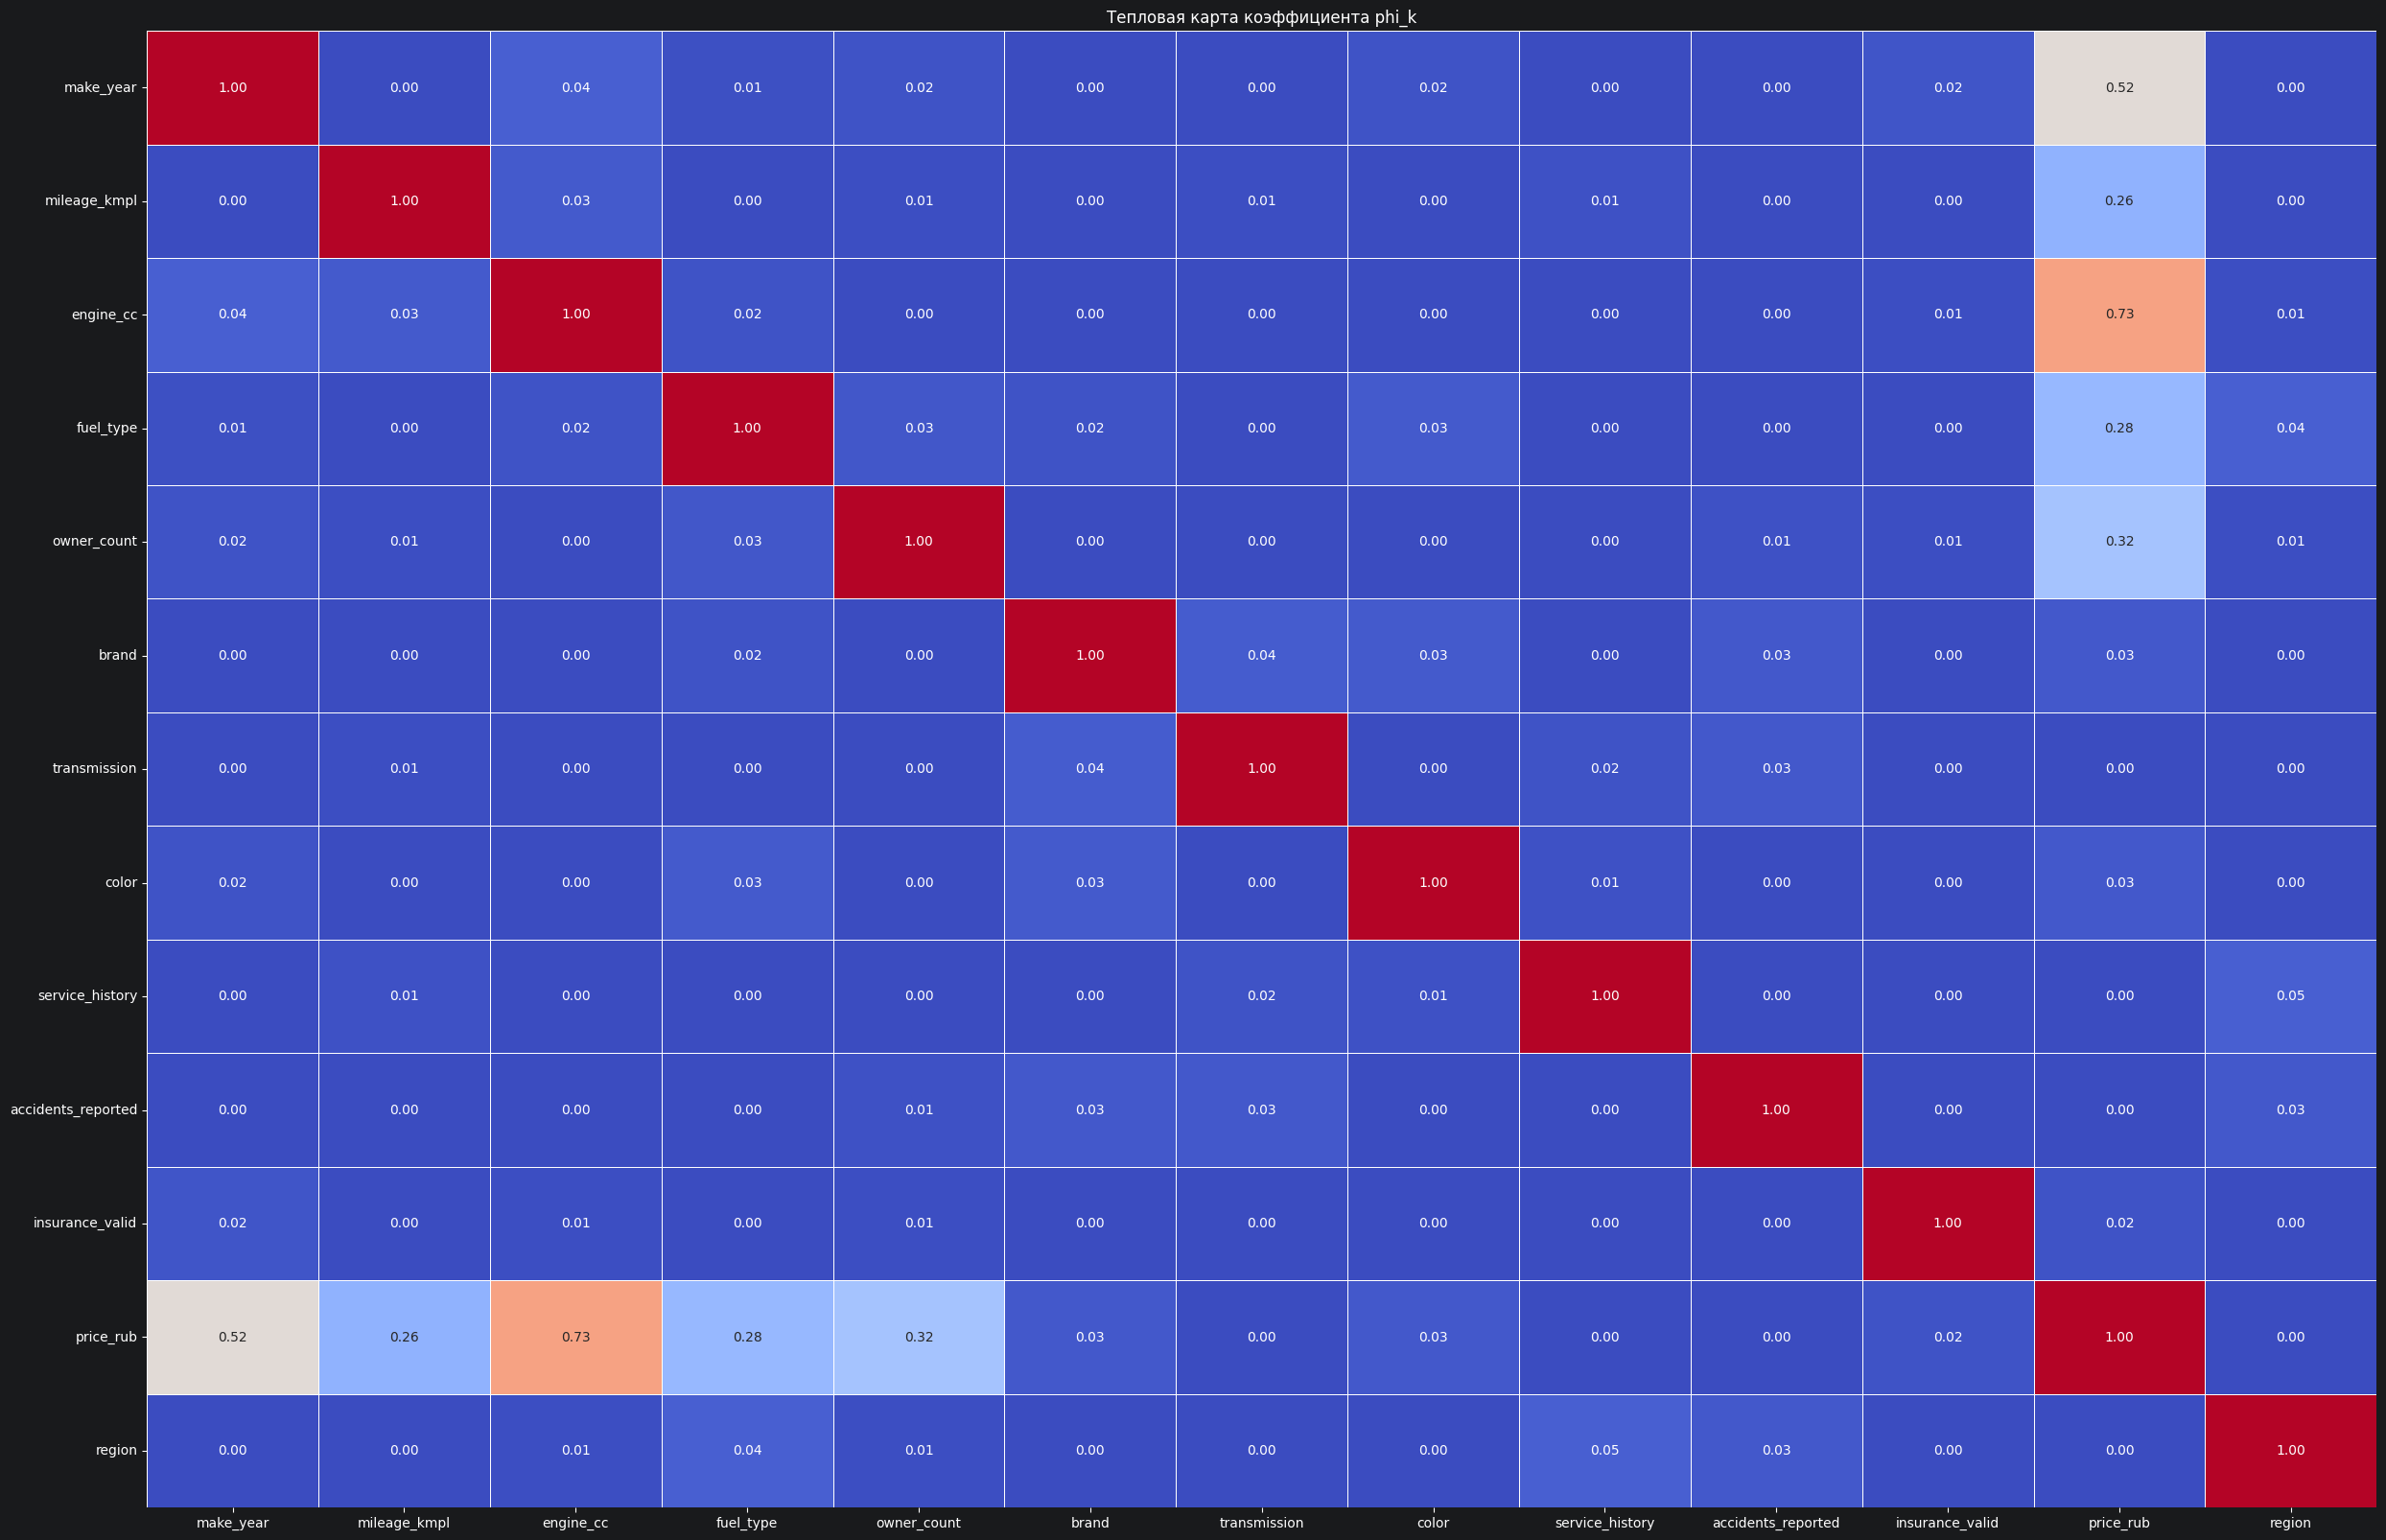

In [15]:
# Строим тепловую карту коэффициента phi_k
plot_heatmap(correlation_matrix)

In [16]:
# Выводим значимые корреляции
target_corr = correlation_matrix['price_rub'].drop('price_rub')

medium_corr = target_corr[(target_corr > 0.2) & (target_corr < 0.5)]
print('Признаки со средней корреляцией')
display(medium_corr)

high_corr = target_corr[target_corr > 0.5]
print('\nПризнаки с высокой корреляцией')
display(high_corr)

Признаки со средней корреляцией


mileage_kmpl    0.261591
fuel_type       0.278533
owner_count     0.318510
Name: price_rub, dtype: float64


Признаки с высокой корреляцией


make_year    0.518584
engine_cc    0.730348
Name: price_rub, dtype: float64

После проведенного первичного анализа видно, что есть 3 признака со средней корреляцией `mileage_kmpl`, `fuel_type`, `owner_count` и 2 признака с высокой корреляцией `make_year` и `engine_cc`.

# **Часть 2. Предобработка**

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.

In [25]:
# Отделим признаки и целевую переменную (price_rub)
X_train_val = datasets['train'].drop(columns='price_rub')
y_train_val = datasets['train']['price_rub']
X_test = datasets['test'].drop(columns='price_rub')
y_test = datasets['test']['price_rub']

In [31]:
cat_columns = [
    'fuel_type', 'brand', 'transmission', 'color',
    'service_history', 'insurance_valid', 'region'
]
num_columns = [
    'make_year', 'engine_cc', 'owner_count', 'accidents_reported',
]
float_columns = [
    'mileage_kmpl'
]

In [32]:
# Класс оптимизации типов данных датафрейма
class DataFrameNormalizer:
    def __init__(self, df):
        self.df = df

    def run(self,
        to_int: list = None,
        to_float: list = None,
        to_category: list = None,
        to_date: list = None
    ) -> pd.DataFrame:
        original_df = self.df.copy()
        if to_int:
            self.to_int(to_int)
        if to_float:
            self.to_float(to_float)
        if to_category:
            self.to_category(to_category)
        if to_date:
            self.to_date(to_date)
        return pd.concat([
            original_df.dtypes.rename('До изменений'),
            self.df.dtypes.rename('После изменений')
        ], axis=1)

    def to_int(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='integer')

    def to_float(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='float')

    def to_category(self, columns: list) -> None:
        for column in columns:
            self.df[column] = self.df[column].astype('category')

    def to_date(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_datetime(self.df[column].astype(str))

In [33]:
#Оптимизация датафрейма X_train_val
DataFrameNormalizer(X_train_val).run(
    to_int=num_columns,
    to_float=float_columns,
    to_category=cat_columns
)

,До изменений,После изменений
make_year,int64,int16
mileage_kmpl,float64,float32
engine_cc,int64,int16
fuel_type,str,category
owner_count,int64,int8
brand,str,category
transmission,str,category
color,str,category
service_history,str,category
accidents_reported,int64,int8


In [34]:
#Оптимизация датафрейма X_test
DataFrameNormalizer(X_test).run(
    to_int=num_columns,
    to_float=float_columns,
    to_category=cat_columns
)

,До изменений,После изменений
make_year,int64,int16
mileage_kmpl,float64,float32
engine_cc,int64,int16
fuel_type,str,category
owner_count,int64,int8
brand,str,category
transmission,str,category
color,str,category
service_history,str,category
accidents_reported,int64,int8


In [35]:
# Выделим train и val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    random_state=RANDOM_STATE,
)


# **Часть 3. Обучение моделей в разных библиотеках**

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

In [199]:
def calc_error_ratio(y_pred_tmp, y_val_tmp):
    return (y_pred_tmp - y_val_tmp) / y_val_tmp

def calc_overpricing_rate(error_ratio):
    return (error_ratio > 0.20).mean()

def calc_underpricing_loss(error_ratio, y_pred_tmp, y_val_tmp):
    under_mask = error_ratio < -0.20
    return (y_val_tmp[under_mask] - y_pred_tmp[under_mask]).sum()

In [236]:

def custom_cv(model, X_tmp, y_tmp, model_name='',
              model_type=None, cats=None, silent=False):
    cv_metrics = {
        'MAE': [], 'RMSE': [], 'R2': [],
        'Overpricing Rate': [], 'Underpricing Loss': [],
    }
    kfold = KFold(
        n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE
    )
    start = time.perf_counter()
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_tmp, y_tmp)):
        X_train_fold = X_tmp.iloc[train_idx]
        X_val_fold = X_tmp.iloc[val_idx]
        y_train_fold = y_tmp.iloc[train_idx]
        y_val_fold = y_tmp.iloc[val_idx]
        match model_type:
            case 'lgbm':
                model.fit(
                    X_train_fold, y_train_fold,
                    categorical_feature=cats,
                )
            case 'catboost':
                model.fit(
                    X_train_fold, y_train_fold,
                    cat_features=cats,
                    verbose=0
                )
            case _:
                model.fit(
                    X_train_fold, y_train_fold,
                )
        y_pred_fold = model.predict(X_val_fold)

        mae = mean_absolute_error(y_val_fold, y_pred_fold)
        rmse = root_mean_squared_error(y_val_fold, y_pred_fold)
        r2 = r2_score(y_val_fold, y_pred_fold)
        cv_metrics['MAE'].append(mae)
        cv_metrics['RMSE'].append(rmse)
        cv_metrics['R2'].append(r2)

        error_ratio = calc_error_ratio(y_pred_fold, y_val_fold)
        overpricing_rate = calc_overpricing_rate(error_ratio)
        cv_metrics['Overpricing Rate'].append(overpricing_rate)

        underpricing_loss = calc_underpricing_loss(
            error_ratio, y_pred_fold, y_val_fold
        )
        cv_metrics['Underpricing Loss'].append(underpricing_loss)

    end = time.perf_counter()
    fit_time = round(end - start, 2)
    if not silent:
        print("Результаты модели:")
        for metric_name in cv_metrics:
            print(f"  {metric_name}: {np.mean(cv_metrics[metric_name]):.3f} "
                  f"(+/- {np.std(cv_metrics[metric_name]):.3f})")
        print(f"Время обучения модели: {fit_time} с.")
    result = dict()
    for name in cv_metrics:
        result[name] = round(np.mean(cv_metrics[name]), 3)

    result_df = pd.DataFrame({
        'model': [
            type(model).__name__
        ],
        'name': model_name,
        'fit_time': fit_time,
        **result
    })
    return result_df


In [275]:
cv_results = pd.DataFrame()

In [276]:
# CV XGBRegressor
xgb_model = XGBRegressor(random_state=RANDOM_STATE, enable_categorical=True)

result = custom_cv(xgb_model, X_train_val, y_train_val, model_name='Base')
cv_results = pd.concat(
        [cv_results, result], axis=0, ignore_index=True)

Результаты модели:
  MAE: 85554.175 (+/- 1865.137)
  RMSE: 107442.288 (+/- 1731.713)
  R2: 0.835 (+/- 0.010)
  Overpricing Rate: 0.155 (+/- 0.009)
  Underpricing Loss: 24116946.036 (+/- 2278662.347)
Время обучения модели: 1.16 с.


In [277]:
# CV LGBMRegressor
lgbm_model = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)

result = custom_cv(
    lgbm_model, X_train_val, y_train_val, model_name='Base',
    model_type='lgbm', cats=cat_columns
)
cv_results = pd.concat(
        [cv_results, result], axis=0, ignore_index=True)

Результаты модели:
  MAE: 78977.419 (+/- 2045.281)
  RMSE: 99231.700 (+/- 2145.504)
  R2: 0.859 (+/- 0.008)
  Overpricing Rate: 0.145 (+/- 0.003)
  Underpricing Loss: 17946988.372 (+/- 1410626.039)
Время обучения модели: 3.83 с.


In [278]:
# CV CatBoostRegressor
catboost_model = CatBoostRegressor(random_state=RANDOM_STATE)

result = custom_cv(
    catboost_model, X_train_val, y_train_val, model_name='Base',
    model_type='catboost', cats=cat_columns
)
cv_results = pd.concat(
        [cv_results, result], axis=0, ignore_index=True)

Результаты модели:
  MAE: 76971.153 (+/- 1961.015)
  RMSE: 96626.297 (+/- 2065.445)
  R2: 0.867 (+/- 0.008)
  Overpricing Rate: 0.139 (+/- 0.003)
  Underpricing Loss: 16636720.697 (+/- 1363510.906)
Время обучения модели: 9.29 с.


In [279]:
#Результаты кроссвалидации базовых моделей
cv_results.sort_values(by='MAE')

,model,name,fit_time,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
2,CatBoostRegressor,Base,9.29,76971.153,96626.297,0.867,0.139,1.663672e+07
1,LGBMRegressor,Base,3.83,78977.419,99231.700,0.859,0.145,1.794699e+07
0,XGBRegressor,Base,1.16,85554.175,107442.288,0.835,0.155,2.411695e+07


По результатам кроссвалидации видно, что CatBoost имеет наименьшее отклонение от предсказания и лучшие бизнес метрики, но при этом модель обучается заметно дольше двух других 8с протис 1с и 3с.

# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


### XGBRegressor

In [280]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000, step=100),

        'gamma': trial.suggest_float('gamma', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0),
    }

    model = XGBRegressor(
        **params,
        random_state=RANDOM_STATE,
        enable_categorical=True
    )
    scores = custom_cv(
        model,
        X_train_val,
        y_train_val,
        silent=True
    )

    return scores['MAE'].iloc[0]

# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler
)
study.optimize(objective, n_trials=30, show_progress_bar=True)


[I 2026-05-29 18:55:29,910] A new study created in memory with name: no-name-a6070a6b-c785-412b-b26f-2088a7fe90e2


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-29 18:56:01,159] Trial 0 finished with value: 86363.342 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1600, 'gamma': 0.5986584882104518, 'reg_lambda': 1.5601864128641787, 'reg_alpha': 1.5599452118020811}. Best is trial 0 with value: 86363.342.
[I 2026-05-29 18:56:26,604] Trial 1 finished with value: 85223.939 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1400, 'gamma': 0.7080725807153196, 'reg_lambda': 0.2058449527521795, 'reg_alpha': 9.699098521920844}. Best is trial 1 with value: 85223.939.
[I 2026-05-29 18:56:31,418] Trial 2 finished with value: 80159.219 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 700, 'gamma': 0.1834045180193887, 'reg_lambda': 3.0424224365529544, 'reg_alpha': 5.2475643210748135}. Best is trial 2 with value: 80159.219.
[I 2026-05-29 18:56:42,333] Trial 3 finished with value: 80971.969 and parameters: {'learning_rate': 0.02703616

In [281]:
# Визуализация результатов XGBRegressor
fig1 = optuna.visualization.plot_optimization_history(study)

# Визуализация важности параметров
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2)

In [282]:
xgb_best_params = study.best_params
xgb_best_value = study.best_value

print(f'XGB лучшие параметры: {xgb_best_params}')
print(f'XGB лучшая MAE: {xgb_best_value:.3f}')

XGB лучшие параметры: {'learning_rate': 0.014190835536659665, 'max_depth': 3, 'n_estimators': 1000, 'gamma': 0.8508917982233571, 'reg_lambda': 4.230819137897658, 'reg_alpha': 4.314078392249338}
XGB лучшая MAE: 77200.561


### LGBMRegressor

In [283]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000, step=100),

        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
    }

    model = LGBMRegressor(
        **params,
        random_state=RANDOM_STATE,
    )
    scores = custom_cv(
        model,
        X_train_val,
        y_train_val,
        silent=True,
        model_type='lgbm',
        cats=cat_columns
    )

    return scores['MAE'].iloc[0]

# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler
)
study.optimize(objective, n_trials=30, show_progress_bar=True)


[I 2026-05-29 19:00:52,047] A new study created in memory with name: no-name-2139c13f-09ed-4e83-850a-18d1217ac45e


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-29 19:03:07,631] Trial 0 finished with value: 84160.114 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1600, 'num_leaves': 161, 'min_child_samples': 19, 'reg_lambda': 0.15599452877625744, 'reg_alpha': 0.058083621587363334}. Best is trial 0 with value: 84160.114.
[I 2026-05-29 19:03:35,706] Trial 1 finished with value: 84418.163 and parameters: {'learning_rate': 0.07348118405270448, 'max_depth': 7, 'n_estimators': 1600, 'num_leaves': 24, 'min_child_samples': 98, 'reg_lambda': 0.8324426424759953, 'reg_alpha': 0.21233911855488505}. Best is trial 0 with value: 84160.114.
[I 2026-05-29 19:03:45,244] Trial 2 finished with value: 77690.877 and parameters: {'learning_rate': 0.015199348301309814, 'max_depth': 4, 'n_estimators': 900, 'num_leaves': 144, 'min_child_samples': 46, 'reg_lambda': 0.2912291472857505, 'reg_alpha': 0.6118528986038505}. Best is trial 2 with value: 77690.877.
[I 2026-05-29 19:03:59,549] Trial 3 finished with value: 78310

In [284]:
# Визуализация результатов LGBMRegressor
fig1 = optuna.visualization.plot_optimization_history(study)

# Визуализация важности параметров
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2)

In [285]:
lgbm_best_params = study.best_params
lgbm_best_value = study.best_value

print(f'LGBM лучшие параметры: {lgbm_best_params}')
print(f'LGBM лучшая MAE: {lgbm_best_value}')

LGBM лучшие параметры: {'learning_rate': 0.020000022918162306, 'max_depth': 3, 'n_estimators': 700, 'num_leaves': 163, 'min_child_samples': 33, 'reg_lambda': 0.3741675541701905, 'reg_alpha': 0.4441400249010632}
LGBM лучшая MAE: 77203.343


### CatBoost

In [286]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'iterations': trial.suggest_int('iterations', 500, 2000, step=100),

        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
    }

    model = CatBoostRegressor(
        **params,
        random_state=RANDOM_STATE,
    )
    scores = custom_cv(
        model,
        X_train_val,
        y_train_val,
        silent=True,
        model_type='catboost',
        cats=cat_columns
    )

    return scores['MAE'].iloc[0]

# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-05-29 19:12:07,727] A new study created in memory with name: no-name-41034155-3e3d-496d-b56d-ff8e4700a708


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-29 19:12:36,153] Trial 0 finished with value: 77679.663 and parameters: {'learning_rate': 0.023688639503640783, 'depth': 10, 'iterations': 1600, 'l2_leaf_reg': 6}. Best is trial 0 with value: 77679.663.
[I 2026-05-29 19:12:39,457] Trial 1 finished with value: 77108.779 and parameters: {'learning_rate': 0.014322493718230255, 'depth': 4, 'iterations': 500, 'l2_leaf_reg': 9}. Best is trial 1 with value: 77108.779.
[I 2026-05-29 19:12:47,355] Trial 2 finished with value: 77066.725 and parameters: {'learning_rate': 0.039913058785616795, 'depth': 8, 'iterations': 500, 'l2_leaf_reg': 10}. Best is trial 2 with value: 77066.725.
[I 2026-05-29 19:12:51,667] Trial 3 finished with value: 76488.187 and parameters: {'learning_rate': 0.06798962421591129, 'depth': 4, 'iterations': 700, 'l2_leaf_reg': 2}. Best is trial 3 with value: 76488.187.
[I 2026-05-29 19:13:05,520] Trial 4 finished with value: 76730.632 and parameters: {'learning_rate': 0.02014847788415866, 'depth': 7, 'iterations': 11

In [287]:
# Визуализация результатов CatBoost
fig1 = optuna.visualization.plot_optimization_history(study)

# Визуализация важности параметров
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2)

In [288]:
catboost_best_params = study.best_params
catboost_best_value = study.best_value

print(f'CatBoost лучшие параметры: {catboost_best_params}')
print(f'CatBoost лучшая MAE: {catboost_best_value}')

CatBoost лучшие параметры: {'learning_rate': 0.020165721691808594, 'depth': 3, 'iterations': 1500, 'l2_leaf_reg': 5}
CatBoost лучшая MAE: 76275.631


In [289]:
# CV XGBRegressor
xgb_best = XGBRegressor(
    **xgb_best_params,
    random_state=RANDOM_STATE,
    enable_categorical=True
)

result = custom_cv(
    xgb_best, X_train_val, y_train_val,
    model_name='Best', silent=True
)
cv_results = pd.concat(
        [cv_results, result], axis=0, ignore_index=True)

# CV LGBMRegressor
lgbm_best = LGBMRegressor(
    **lgbm_best_params,
    random_state=RANDOM_STATE,
    verbose=-1
)

result = custom_cv(
    lgbm_best, X_train_val, y_train_val, model_name='Best',
    model_type='lgbm', cats=cat_columns,
    silent=True
)
cv_results = pd.concat(
        [cv_results, result], axis=0, ignore_index=True)

# CV CatBoostRegressor
catboost_best = CatBoostRegressor(
    **catboost_best_params,
    random_state=RANDOM_STATE
)

result = custom_cv(
    catboost_best, X_train_val, y_train_val, model_name='Best',
    model_type='catboost', cats=cat_columns,
    silent=True
)
cv_results = pd.concat(
        [cv_results, result], axis=0, ignore_index=True)

In [290]:
cv_results.sort_values(by='MAE')

,model,name,fit_time,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
5,CatBoostRegressor,Best,7.30,76275.631,95787.674,0.869,0.136,1.574518e+07
2,CatBoostRegressor,Base,9.29,76971.153,96626.297,0.867,0.139,1.663672e+07
3,XGBRegressor,Best,5.97,77200.561,97126.612,0.865,0.140,1.606248e+07
4,LGBMRegressor,Best,5.66,77203.343,97113.516,0.865,0.140,1.620745e+07
1,LGBMRegressor,Base,3.83,78977.419,99231.700,0.859,0.145,1.794699e+07
0,XGBRegressor,Base,1.16,85554.175,107442.288,0.835,0.155,2.411695e+07


Лучшей оптимизированной моделью стала CatBoost, следом за ней идет CatBoost, но с базовыми гиперпараметрами.

# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?


---

In [303]:
#Обучаем лучшие модели
xgb_best_model = XGBRegressor(
    **xgb_best_params,
    random_state=RANDOM_STATE,
    enable_categorical=True

)
xgb_best_model.fit(
    X_train, y_train,
)

lgbm_best_model = LGBMRegressor(
    **lgbm_best_params,
    random_state=RANDOM_STATE

)
lgbm_best_model.fit(
    X_train, y_train,
    categorical_feature=cat_columns,
)

catboost_best_model = CatBoostRegressor(
    **catboost_best_params,
    random_state=RANDOM_STATE
)
catboost_best_model.fit(
    X_train, y_train,
    cat_features=cat_columns,
    verbose=0
)

CatBoostRegressor(depth=3, iterations=1500, l2_leaf_reg=5, learning_rate=0.020165721691808594, loss_function='RMSE', random_state=42)

In [327]:
# Summary Plot для всех признаков
def plot_shap_summary(shap_values, X_tmp, name=''):
    if name:
        plt.title(f"SHAP Summary Plot ({name})", fontsize=16)
    else:
        plt.title("SHAP Summary Plot", fontsize=16)
    shap.summary_plot(shap_values, X_tmp, show=False)
    plt.tight_layout()
    plt.show()

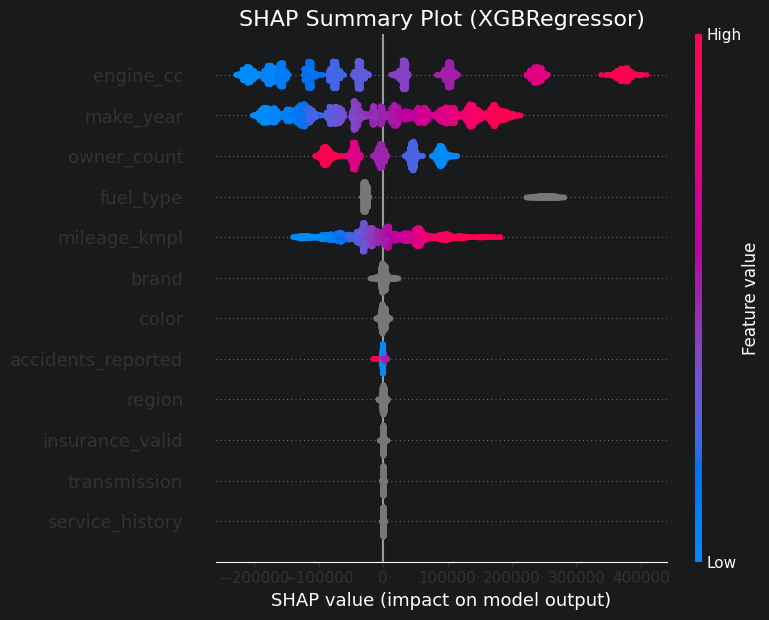

In [328]:
explainer = shap.TreeExplainer(xgb_best_model)
shap_values = explainer.shap_values(X_train)

plot_shap_summary(shap_values, X_train, type(xgb_best_model).__name__)

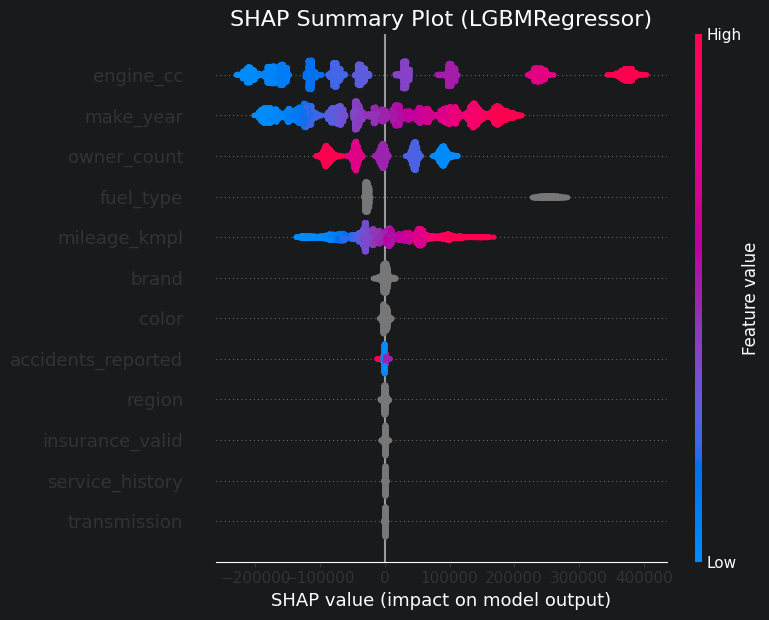

In [329]:
explainer = shap.TreeExplainer(lgbm_best_model)
shap_values = explainer.shap_values(X_train)

plot_shap_summary(shap_values, X_train, type(lgbm_best_model).__name__)

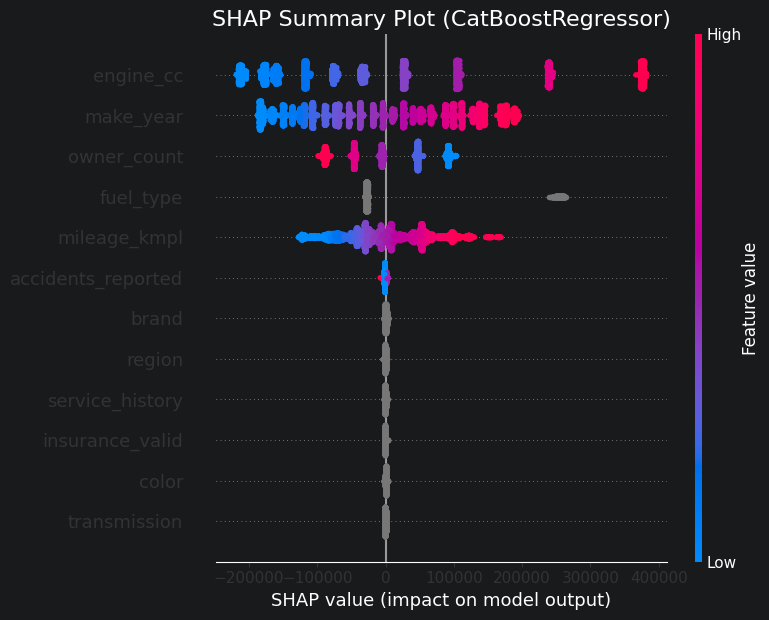

In [330]:
explainer = shap.TreeExplainer(catboost_best_model)
shap_values = explainer.shap_values(X_train)

plot_shap_summary(shap_values, X_train, type(catboost_best_model).__name__)

Все три модели подобным образом оценивают важность признаков, XGB и LGBM подобным образом оценивает важность признаков. На графике CatBoost есть отличия, параметры более сгруппированны на определенных отметках.
Наиболее важные признаки для моделей:
- `engine_cc` - прямая зависимость
- `make_year` - прямая зависимость
- `owner_count` - обратная зависимость
- `fuel_type` - категорийный параметр, вероятно дизель сильнее влияет на цену
- `mileage_kmpl` - прямая зависимость.

Модели практически игнорируют параметры brand, region, insurance_valid, color, service_history и transmission. Такое же поведение мы видим и на матрице корреляции (phik).

В реальной жизни на цену авто сильно влияют такие признаки как `brand`, `transmission`.

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.



In [331]:
cv_results[cv_results['name'] == 'Best'].sort_values(by='MAE')

,model,name,fit_time,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
5,CatBoostRegressor,Best,7.30,76275.631,95787.674,0.869,0.136,1.574518e+07
3,XGBRegressor,Best,5.97,77200.561,97126.612,0.865,0.140,1.606248e+07
4,LGBMRegressor,Best,5.66,77203.343,97113.516,0.865,0.140,1.620745e+07


In [341]:
def evaluate_model(model, X_tmp, y_tmp):
    y_pred = model.predict(X_tmp)

    mae = mean_absolute_error(y_tmp, y_pred)
    rmse = root_mean_squared_error(y_tmp, y_pred)
    r2 = r2_score(y_tmp, y_pred)

    error_ratio = calc_error_ratio(y_pred, y_tmp)
    overpricing_rate = calc_overpricing_rate(error_ratio)

    underpricing_loss = calc_underpricing_loss(
        error_ratio, y_pred, y_tmp
    )
    print(f'Отчет по модели {type(model).__name__}')
    print(f'MAE:\t{mae:.3f}')
    print(f'RMSE:\t{rmse:.3f}')
    print(f'R2:\t\t{r2:.3f}')
    print(f'overpricing_rate:\t{overpricing_rate:.3f}')
    print(f'underpricing_loss:\t{underpricing_loss:.3f}')


In [342]:
evaluate_model(xgb_best_model, X_val, y_val)

Отчет по модели XGBRegressor
MAE:	80169.047
RMSE:	100181.430
R2:		0.852
overpricing_rate:	0.139
underpricing_loss:	18965152.703


In [343]:
evaluate_model(lgbm_best_model, X_val, y_val)

Отчет по модели LGBMRegressor
MAE:	80168.929
RMSE:	100281.262
R2:		0.852
overpricing_rate:	0.138
underpricing_loss:	19229632.898


In [344]:
evaluate_model(catboost_best_model, X_val, y_val)

Отчет по модели CatBoostRegressor
MAE:	79348.996
RMSE:	98931.899
R2:		0.855
overpricing_rate:	0.133
underpricing_loss:	17840545.868


Модель CatBoostRegressor на валидационной выборке показала лучший презультат по всем метрикам MSE (79348руб.), процент завышеных выкупов составил 13.3% а сумма недополученой прибыли составил 1.78М.
При этом достаточно стабильной, на трейне MSE 76275 против 79348 на валидации. overpricing rate 13.6%(train) против 13.3%(val), а underpricing loss 15.7М(train) против 17.8М(val).


**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

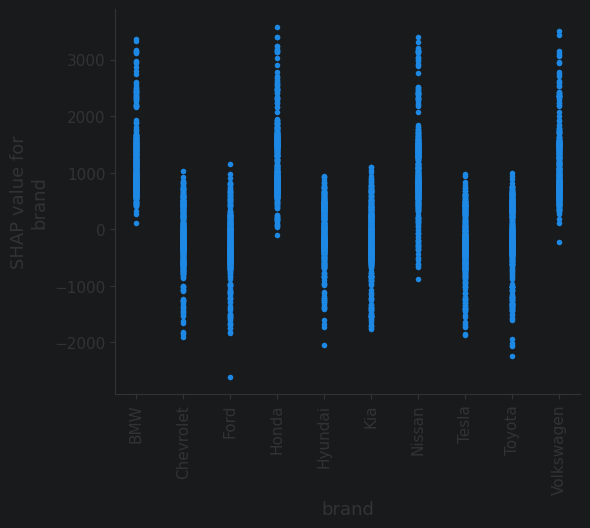

In [345]:
shap.dependence_plot('brand', shap_values, X_train, interaction_index=None)

Модель занижает цену автомобилей брендов Hundai, Kia, Tesla и Toyota, хотя автомобили Toyoram Kia и Hundai высоко ценятся на вторичном рынке из-за своей надежности. Для автомобилей этих марок потребуется ручная проверка экспеортом.

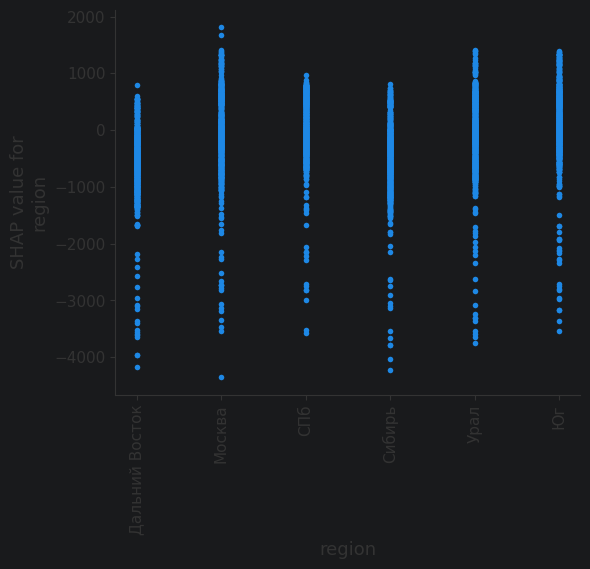

In [346]:
shap.dependence_plot('region', shap_values, X_train, interaction_index=None)

Традиционно в России Далаьний Восток и Москва являются самыми дорогими рынками на вторичном рынке. Экспертам нужно будет вручную проверять недооцененные авто на Дальнем востоке.

# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

In [347]:
#Оценка модели на test
evaluate_model(catboost_best_model, X_test, y_test)


Отчет по модели CatBoostRegressor
MAE:	75634.331
RMSE:	94862.918
R2:		0.875
overpricing_rate:	0.134
underpricing_loss:	19314371.251


На тесте модель показала чуть лучший результат чем на трейне по ключевой метрике MAE 75634(test) против 76275(train), overpricing rate 13.4%(test) против 13.6%(train), underpricing loss 19.3М(test) против 15.7М(train).
По результатам теста можно утверждать, что модель стабильна и готова к продакшену.

 # **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [Название вашей лучшей модели, например]

2. Точность оценки: в среднем модель ошибается на [Ваше MAE] руб. Коэффициент детерминации равен[Ваше $R^2$], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [Ваш %]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [Сумма Underpricing Loss] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Ваш проблемный регион] и на марках [Ваши проблемные марки].

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение.

---

1. Рекомендованная модель: [CatBoostRegressor]

2. Точность оценки: в среднем модель ошибается на [`75634`] руб. Коэффициент детерминации равен[`0.875`], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [`13.4%`]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [`19314371`] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [`Дальний Восток`] и на марках [`Toyota`, `Kia`, `Hyndai`].

6. Лучшие гиперпараметры для модели [`learning_rate`: 0.020165721691808594, `depth`: 3, `iterations`: 1500, `l2_leaf_reg`: 5].

https://github.com/msesemov/DS_GradientBoosting_Sprint_16